# Week 7: Limited Robustness Check

## Methods

This notebook evaluates how the best model (ViT v2) performs when test images are
degraded through compression and noise, simulating real-world conditions where deepfake
images may be shared through social media, messaging apps, or low-quality sources.

**Perturbations applied:**
1. JPEG compression at quality levels 90, 70, 50, 30, 10
2. Gaussian noise at sigma levels 5, 15, 25, 50
3. Downscale-upscale (resize to 112x112 then back to 224x224, simulating low-res sharing)

Each perturbation is applied to the full test set. The model is not retrained; only
inference is performed on the degraded images. Performance is measured using AUC-ROC
and macro F1, consistent with previous weeks.

**Baseline:** Unperturbed test set performance (AUC = 0.8409, macro F1 = 0.72)

**Class label orientation:** fake=0, real=1. Fake is the positive class.

**GPU:** NVIDIA Tesla T4 (inference only).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q -o /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score, classification_report, f1_score
import timm
import cv2
import io
import os, random, json

SEED = 301
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DATA_DIR = '/content/frames'
CHECKPOINT_DIR = '/content/drive/MyDrive/deepfake_capstone/checkpoints/'
RESULTS_DIR = '/content/drive/MyDrive/deepfake_capstone/results/'
BATCH_SIZE = 64
NUM_WORKERS = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using: {device}, GPU: {torch.cuda.get_device_name(0)}")

Using: cuda, GPU: Tesla T4


In [ ]:
model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)
state_dict = torch.load(os.path.join(CHECKPOINT_DIR, 'vit_base16_v2_RETRAIN.pth'),
                         map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()
print("ViT v2 loaded.")

ViT v2 loaded.


## Degradation Pipeline

The approach is to take the clean test set and apply "damage" to every image before
feeding it to the model, simulating real-world conditions where images lose quality.

**DegradedDataset** is a wrapper around the test set. Instead of loading a clean image
and passing it straight to the model, it applies a degradation function first, then
applies the standard normalization. The model never sees clean images during this
evaluation.

Three types of degradation are tested:

**JPEG compression** simulates what happens when images are saved and reshared on social
media. Every JPEG save loses some detail. Quality 90 is nearly lossless. Quality 10
produces the blurry, blocky images typical of content that has been screenshotted and
reshared multiple times. The function saves the image to a JPEG buffer at a given
quality level, then loads it back, reproducing the compression artifacts.

**Gaussian noise** adds random static to every pixel, simulating sensor noise from low
quality cameras or noisy transmission. Sigma controls intensity: sigma 5 is barely
visible, sigma 50 makes the image look like it was captured in near darkness with a
cheap sensor.

**Downscale-upscale** shrinks the image to half resolution (112x112) then stretches it
back to 224x224. This simulates the quality loss from screenshot pipelines where
content is captured at lower resolution and reshared at the original size. Fine details
like facial boundaries and texture are lost in the process.

The model is not retrained for any of these conditions. The goal is to measure how
much performance degrades when the input quality drops, identifying the model's
robustness limits for real-world deployment.

In [ ]:
class DegradedDataset(Dataset):
    """
    Wraps an ImageFolder dataset and applies a degradation function
    to each image before the standard transform.
    """
    def __init__(self, base_dataset, degrade_fn, transform):
        self.base_dataset = base_dataset
        self.degrade_fn = degrade_fn
        self.transform = transform

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        path, label = self.base_dataset.samples[idx]
        img = Image.open(path).convert('RGB')

        # Apply degradation
        img = self.degrade_fn(img)

        # Apply standard normalization
        if self.transform:
            img = self.transform(img)

        return img, label


# Degradation functions
def jpeg_compress(quality):
    """Return a function that JPEG-compresses an image at the given quality."""
    def fn(img):
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=quality)
        buffer.seek(0)
        return Image.open(buffer).convert('RGB')
    return fn

def gaussian_noise(sigma):
    """Return a function that adds Gaussian noise with the given sigma."""
    def fn(img):
        arr = np.array(img).astype(np.float32)
        noise = np.random.normal(0, sigma, arr.shape).astype(np.float32)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)
    return fn

def downscale_upscale(small_size):
    """Return a function that downscales then upscales, simulating low-res sharing."""
    def fn(img):
        small = img.resize((small_size, small_size), Image.BILINEAR)
        return small.resize((224, 224), Image.BILINEAR)
    return fn

def no_degradation(img):
    """Identity function for baseline."""
    return img

In [ ]:
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Base test dataset (without transforms, we apply them in DegradedDataset)
base_test = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'))

def evaluate_degradation(model, degrade_fn, degrade_name):
    """Evaluate model on degraded test set and return metrics."""
    dataset = DegradedDataset(base_test, degrade_fn, val_transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = (all_probs > 0.5).astype(int)

    auc = roc_auc_score(all_labels, all_probs)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    accuracy = (all_preds == all_labels).mean()

    # Per-class recall
    fake_mask = all_labels == 0
    real_mask = all_labels == 1
    fake_recall = (all_preds[fake_mask] == 0).mean()
    real_recall = (all_preds[real_mask] == 1).mean()

    return {
        'name': degrade_name,
        'auc': auc,
        'macro_f1': macro_f1,
        'accuracy': accuracy,
        'fake_recall': fake_recall,
        'real_recall': real_recall
    }

In [ ]:
perturbations = [
    ('Baseline (no degradation)', no_degradation),
    ('JPEG Q=90', jpeg_compress(90)),
    ('JPEG Q=70', jpeg_compress(70)),
    ('JPEG Q=50', jpeg_compress(50)),
    ('JPEG Q=30', jpeg_compress(30)),
    ('JPEG Q=10', jpeg_compress(10)),
    ('Noise σ=5', gaussian_noise(5)),
    ('Noise σ=15', gaussian_noise(15)),
    ('Noise σ=25', gaussian_noise(25)),
    ('Noise σ=50', gaussian_noise(50)),
    ('Downscale 112→224', downscale_upscale(112)),
]

results = []
for name, fn in perturbations:
    print(f"Evaluating: {name}...", end=' ')
    r = evaluate_degradation(model, fn, name)
    results.append(r)
    print(f"AUC={r['auc']:.4f}, F1={r['macro_f1']:.4f}")

print("\nAll perturbations evaluated.")

Evaluating: Baseline (no degradation)... AUC=0.8409, F1=0.7244
Evaluating: JPEG Q=90... AUC=0.8400, F1=0.7216
Evaluating: JPEG Q=70... AUC=0.8179, F1=0.6901
Evaluating: JPEG Q=50... AUC=0.7986, F1=0.6619
Evaluating: JPEG Q=30... AUC=0.7763, F1=0.6250
Evaluating: JPEG Q=10... AUC=0.7114, F1=0.4955
Evaluating: Noise σ=5... AUC=0.8159, F1=0.7340
Evaluating: Noise σ=15... AUC=0.7637, F1=0.6464
Evaluating: Noise σ=25... AUC=0.7276, F1=0.5168
Evaluating: Noise σ=50... AUC=0.6553, F1=0.3182
Evaluating: Downscale 112→224... AUC=0.7586, F1=0.6759

All perturbations evaluated.


In [ ]:
print(f"\n{'Perturbation':<26} {'AUC-ROC':>9} {'Macro F1':>10} {'Accuracy':>10} {'Fake Rec':>10} {'Real Rec':>10}")
print("=" * 77)

baseline_auc = results[0]['auc']
baseline_f1 = results[0]['macro_f1']

for r in results:
    auc_delta = r['auc'] - baseline_auc
    f1_delta = r['macro_f1'] - baseline_f1
    delta_str = f"({auc_delta:+.4f})" if r['name'] != 'Baseline (no degradation)' else ""
    print(f"{r['name']:<26} {r['auc']:>9.4f} {r['macro_f1']:>10.4f} {r['accuracy']:>10.4f} "
          f"{r['fake_recall']:>10.4f} {r['real_recall']:>10.4f}  {delta_str}")


Perturbation                 AUC-ROC   Macro F1   Accuracy   Fake Rec   Real Rec
Baseline (no degradation)     0.8409     0.7244     0.7280     0.6533     0.8640  
JPEG Q=90                     0.8400     0.7216     0.7249     0.6463     0.8679  (-0.0009)
JPEG Q=70                     0.8179     0.6901     0.6918     0.5949     0.8682  (-0.0230)
JPEG Q=50                     0.7986     0.6619     0.6624     0.5452     0.8756  (-0.0423)
JPEG Q=30                     0.7763     0.6250     0.6250     0.4809     0.8870  (-0.0646)
JPEG Q=10                     0.7114     0.4955     0.5049     0.2855     0.9037  (-0.1294)
Noise σ=5                     0.8159     0.7340     0.7453     0.7368     0.7607  (-0.0250)
Noise σ=15                    0.7637     0.6464     0.6496     0.5768     0.7820  (-0.0772)
Noise σ=25                    0.7276     0.5168     0.5223     0.3226     0.8853  (-0.1133)
Noise σ=50                    0.6553     0.3182     0.3849     0.0559     0.9833  (-0.1855)
Downsca

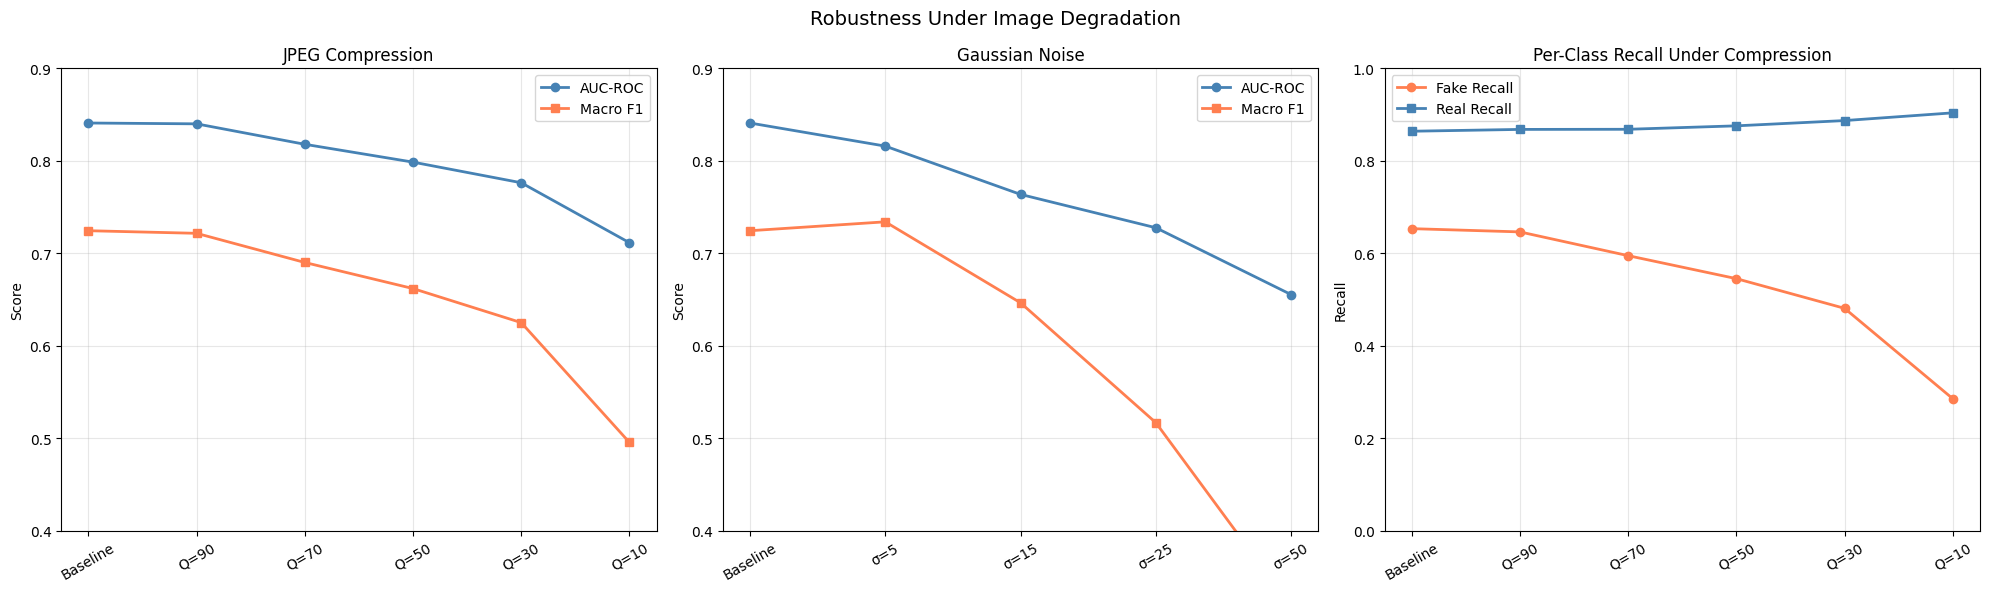

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# JPEG compression
jpeg_results = [r for r in results if 'JPEG' in r['name'] or 'Baseline' in r['name']]
jpeg_results_only = [r for r in results if 'JPEG' in r['name']]
jpeg_labels = ['Baseline'] + [r['name'].replace('JPEG ', '') for r in jpeg_results_only]
jpeg_aucs = [results[0]['auc']] + [r['auc'] for r in jpeg_results_only]
jpeg_f1s = [results[0]['macro_f1']] + [r['macro_f1'] for r in jpeg_results_only]

axes[0].plot(jpeg_labels, jpeg_aucs, 'o-', color='steelblue', label='AUC-ROC', linewidth=2)
axes[0].plot(jpeg_labels, jpeg_f1s, 's-', color='coral', label='Macro F1', linewidth=2)
axes[0].set_title('JPEG Compression', fontsize=12)
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.4, 0.9)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=30)

# Gaussian noise
noise_results = [r for r in results if 'Noise' in r['name']]
noise_labels = ['Baseline'] + [r['name'].replace('Noise ', '') for r in noise_results]
noise_aucs = [results[0]['auc']] + [r['auc'] for r in noise_results]
noise_f1s = [results[0]['macro_f1']] + [r['macro_f1'] for r in noise_results]

axes[1].plot(noise_labels, noise_aucs, 'o-', color='steelblue', label='AUC-ROC', linewidth=2)
axes[1].plot(noise_labels, noise_f1s, 's-', color='coral', label='Macro F1', linewidth=2)
axes[1].set_title('Gaussian Noise', fontsize=12)
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.4, 0.9)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=30)

# Per-class recall under JPEG compression
axes[2].plot(jpeg_labels, [results[0]['fake_recall']] + [r['fake_recall'] for r in jpeg_results_only],
             'o-', color='coral', label='Fake Recall', linewidth=2)
axes[2].plot(jpeg_labels, [results[0]['real_recall']] + [r['real_recall'] for r in jpeg_results_only],
             's-', color='steelblue', label='Real Recall', linewidth=2)
axes[2].set_title('Per-Class Recall Under Compression', fontsize=12)
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0.0, 1.0)
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Robustness Under Image Degradation', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'robustness_degradation.png'), dpi=150)
plt.show()

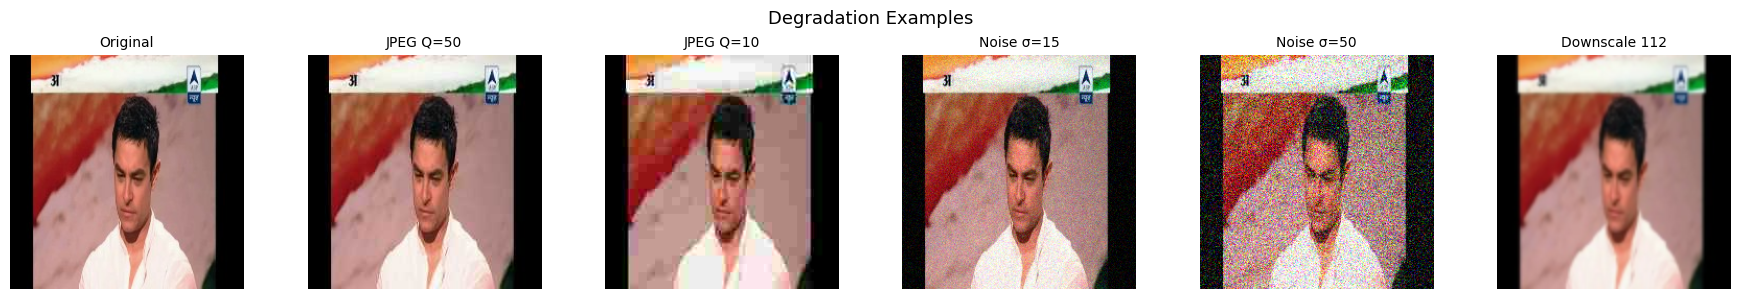

In [ ]:
# Show what each degradation looks like on a sample image
sample_path = base_test.samples[0][0]
sample_img = Image.open(sample_path).convert('RGB')

examples = [
    ('Original', no_degradation),
    ('JPEG Q=50', jpeg_compress(50)),
    ('JPEG Q=10', jpeg_compress(10)),
    ('Noise σ=15', gaussian_noise(15)),
    ('Noise σ=50', gaussian_noise(50)),
    ('Downscale 112', downscale_upscale(112)),
]

fig, axes = plt.subplots(1, len(examples), figsize=(18, 3))
for ax, (name, fn) in zip(axes, examples):
    degraded = fn(sample_img)
    ax.imshow(degraded)
    ax.set_title(name, fontsize=10)
    ax.axis('off')

plt.suptitle('Degradation Examples', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'degradation_examples.png'), dpi=150)
plt.show()

**Robustness Interpretation:**

**JPEG Compression:** Performance begins to decline at Q=70, where AUC-ROC drops to 0.8179
from the baseline of 0.8409. AUC-ROC and Macro F1 decline in parallel across the compression
scale, with the most severe degradation occurring at Q=10 (AUC-ROC: 0.7114, Macro F1: 0.4955).
At Q=10 the model loses discriminative ability and approaches random guessing.

**Gaussian Noise:** Unlike the compression test, AUC-ROC and Macro F1 do not decline in
parallel under noise. Macro F1 increases slightly to approximately 0.68 at σ=5, then
declines with the sharpest drop occurring between σ=25 and σ=50. AUC-ROC shows a more
gradual, stable decline across noise levels. The divergence between these two metrics,
combined with the sharp Macro F1 decline, indicates the model relies on fine-grained
texture features that noise destroys. However, Macro F1 never falls below 0.50, indicating
the model retains some discriminative ability even under heavy noise rather than reverting
to random guessing.

**Downscale-Upscale:** Performance drops compared to baseline. AUC-ROC falls from 0.8409 to
0.7586, a substantial decrease of approximately 8%. Macro F1 declines more modestly. This
degradation simulates the common scenario of a user screenshotting and resharing content,
indicating the model is moderately vulnerable to resolution loss from these pipelines.

**Per-Class Impact:** Under JPEG compression, fake recall and real recall respond
differently. Real recall increases slightly from baseline through Q=10, while
fake recall drops dramatically from 0.65 to 0.29. Compression
removes the fine details that the model relies on for detecting manipulation artifacts,
causing fake detection to deteriorate while real classification remains stable or
slightly improves.

**Overall Robustness Assessment:** The model maintains acceptable robustness through Q=50,
where AUC-ROC and Macro F1 drops remain moderate. Below Q=50, performance degrades with
increasing momentum, and at Q=10 the model becomes too fragile for reliable detection.
Since most social media platforms compress images to Q=70-85, the model is reasonably
robust for typical sharing conditions but would fail on heavily compressed or repeatedly
reshared content.

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save robustness table as JSON
with open(os.path.join(RESULTS_DIR, 'week7_robustness.json'), 'w') as f:
    json.dump(results, f, indent=2)

print("Week 7 artifacts saved.")
print("\nFiles:")
for f_name in ['robustness_degradation.png', 'degradation_examples.png', 'week7_robustness.json']:
    path = os.path.join(RESULTS_DIR, f_name)
    if os.path.exists(path):
        print(f"  ✓ {f_name}")
    else:
        print(f"  ✗ {f_name}")

Week 7 artifacts saved.

Files:
  ✓ robustness_degradation.png
  ✓ degradation_examples.png
  ✓ week7_robustness.json


# Summary

Evaluated ViT v2 robustness across 10 degradation conditions: 5 JPEG compression levels
(Q=90 to Q=10), 4 Gaussian noise levels (σ=5 to σ=50), and one downscale-upscale test
(112 to 224).

**JPEG Compression:** Performance remained stable through Q=70 (AUC: 0.8179), with
meaningful degradation appearing below Q=50 (AUC: 0.7986). At Q=10, AUC dropped to 0.7114,
approximately a 15% decrease from the baseline of 0.8409, rendering predictions unreliable.
The model can withstand the typical compression encountered on social media platforms (Q=70-85)
but is vulnerable to extreme quality loss beyond that range.

**Gaussian Noise:** Noise had a more severe impact on robustness than compression. The
model maintained acceptable performance through σ=15, after which it became too fragile
for reliable detection. Unlike compression, the model never fully lost its ability to
make predictions even under heavy noise. However, its reliance on fine textures and
boundary features makes it particularly sensitive to additive noise, which degrades those
features faster than compression does.

**Downscale-Upscale:** Simulating the common scenario of screenshots being resized and
reshared, the model's AUC decreased from 0.8409 to 0.7586, approximately 8%. Macro F1
declines more modestly. This indicates a meaningful vulnerability to the resolution loss
typical of content spreading through screenshot pipelines.

**Per-Class Impact:** Across all degradation types, fake recall degrades faster than real
recall. Under compression, real recall maintains its quality while fake recall drops
sharply, indicating that the manipulation artifacts the model relies on for fake
classification degrade faster than the natural facial features used for real
classification. This pattern holds under noise, where fake recall declines steeply while
real recall gains ground, producing the false negatives that drive down AUC-ROC and Macro
F1. The downscale-upscale test shows more balanced degradation, with fake and real recall
separated by only 0.068, indicating greater resistance to resolution loss than to
compression or noise.

**Overall Assessment:** The model is viable for deployment under typical social media
conditions (moderate compression, minimal noise) but cannot withstand the full range of
image degradation it would encounter in unconstrained environments. Beyond certain
degradation thresholds, the manipulation features the model relies on for fake detection
are destroyed, causing fake images to be misclassified as real at increasing rates. A
production system would need to account for expected image quality in its deployment
context and potentially reject or flag images that fall below a quality threshold where
detection reliability breaks down.